# Pain & Opportunity Research Dashboard

Analysis of business pains solvable by AI agents. Data comes from the 3-stage pipeline:
`sources.csv` -> `pains.csv` -> `opportunities.csv`

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

data_dir = Path("../data")

sources = pd.read_csv(data_dir / "sources.csv")
pains = pd.read_csv(data_dir / "pains.csv")
opps = pd.read_csv(data_dir / "opportunities.csv")

print(f"Sources explored: {len(sources)}")
print(f"Pains discovered: {len(pains)}")
print(f"Opportunities graduated: {len(opps)}")

Sources explored: 23
Pains discovered: 25
Opportunities graduated: 10


## Research Pipeline Funnel
How many pains at each stage of the pipeline?

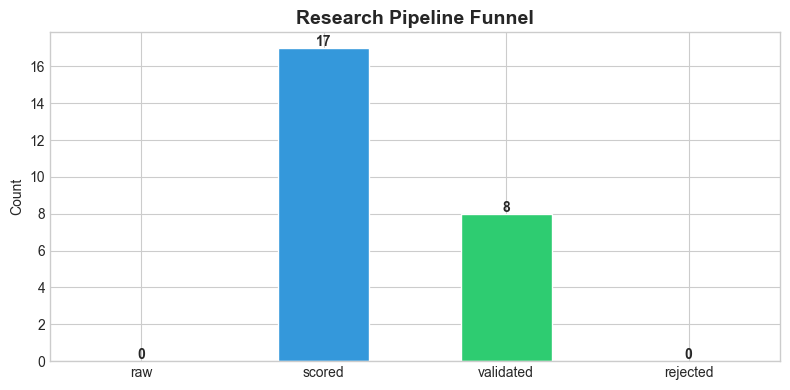

In [3]:
if len(pains) > 0:
    status_order = ["raw", "scored", "validated", "rejected"]
    status_counts = pains["status"].value_counts().reindex(status_order, fill_value=0)

    colors = {"raw": "#95a5a6", "scored": "#3498db", "validated": "#2ecc71", "rejected": "#e74c3c"}
    bar_colors = [colors.get(s, "#95a5a6") for s in status_order]

    fig, ax = plt.subplots(figsize=(8, 4))
    status_counts.plot(kind="bar", color=bar_colors, ax=ax, edgecolor="white")
    ax.set_title("Research Pipeline Funnel", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for i, v in enumerate(status_counts.values):
        ax.text(i, v + 0.1, str(v), ha="center", fontweight="bold")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No pains data yet. Run a research session to populate data/pains.csv.")

## Pain Prioritization Matrix
Scatter plot of **Pain Cost** (y-axis) vs **Solution Ease** (x-axis).
Top-right quadrant = high cost pains that are easy to solve = best opportunities.

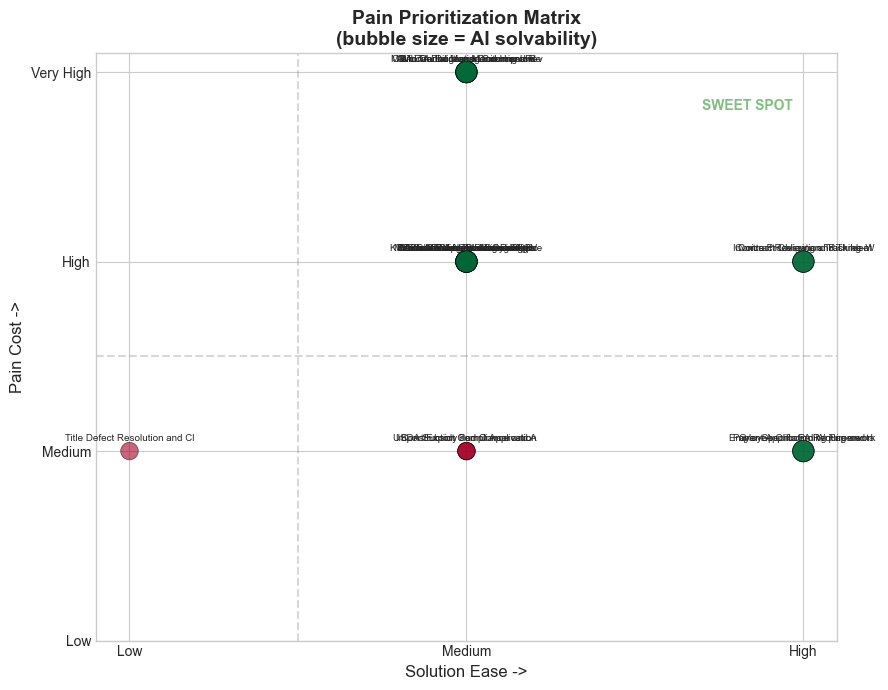

In [4]:
if len(pains) > 0:
    cost_map = {"Low": 1, "Medium": 2, "High": 3, "Very High": 4}
    ease_map = {"Low": 1, "Medium": 2, "High": 3}
    solv_map = {"Low": 1, "Medium": 2, "High": 3}

    scored = pains[pains["status"].isin(["scored", "validated"])].copy()
    if len(scored) > 0:
        scored["cost_num"] = scored["pain_cost"].map(cost_map)
        scored["ease_num"] = scored["solution_ease"].map(ease_map)
        scored["solv_num"] = scored["ai_solvability"].map(solv_map)

        fig, ax = plt.subplots(figsize=(9, 7))
        scatter = ax.scatter(
            scored["ease_num"],
            scored["cost_num"],
            s=scored["solv_num"] * 80,
            alpha=0.6,
            c=scored["solv_num"],
            cmap="RdYlGn",
            edgecolors="black",
            linewidth=0.5,
        )
        for _, row in scored.iterrows():
            ax.annotate(
                row["pain_name"][:30],
                (row["ease_num"], row["cost_num"]),
                fontsize=7,
                ha="center",
                va="bottom",
                textcoords="offset points",
                xytext=(0, 6),
            )
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(["Low", "Medium", "High"])
        ax.set_yticks([1, 2, 3, 4])
        ax.set_yticklabels(["Low", "Medium", "High", "Very High"])
        ax.set_xlabel("Solution Ease ->", fontsize=12)
        ax.set_ylabel("Pain Cost ->", fontsize=12)
        ax.set_title("Pain Prioritization Matrix\n(bubble size = AI solvability)", fontsize=14, fontweight="bold")

        ax.axhline(y=2.5, color="gray", linestyle="--", alpha=0.3)
        ax.axvline(x=1.5, color="gray", linestyle="--", alpha=0.3)
        ax.text(2.7, 3.8, "SWEET SPOT", fontsize=10, color="green", alpha=0.5, fontweight="bold")

        plt.tight_layout()
        plt.show()
    else:
        print("No scored/validated pains yet. Score some raw pains first.")
else:
    print("No pains data yet.")

## Pains by Industry
Distribution of discovered pains across industries.

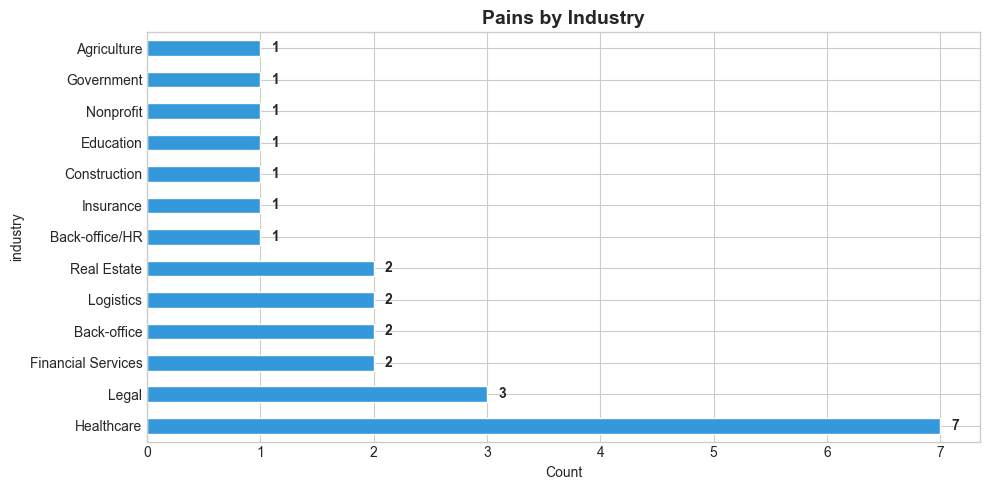

In [5]:
if len(pains) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    industry_counts = pains["industry"].value_counts()
    industry_counts.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
    ax.set_title("Pains by Industry", fontsize=14, fontweight="bold")
    ax.set_xlabel("Count")
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    for i, v in enumerate(industry_counts.values):
        ax.text(v + 0.1, i, str(v), va="center", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No pains data yet.")

## Best Opportunities
Opportunities sorted by priority score (highest first).

In [6]:
if len(opps) > 0:
    best = opps.sort_values("priority_score", ascending=False).copy()
    if len(pains) > 0:
        best = best.merge(
            pains[["id", "pain_name", "industry", "pain_cost", "ai_solvability"]],
            left_on="pain_id",
            right_on="id",
            suffixes=("", "_pain"),
        )
    display_cols = [
        "priority_score", "pain_name", "industry", "proposed_solution",
        "revenue_model", "target_customer", "estimated_complexity", "competition_notes"
    ]
    available_cols = [c for c in display_cols if c in best.columns]
    display(best[available_cols].style
        .background_gradient(subset=["priority_score"], cmap="RdYlGn")
        .format({"priority_score": "{:.1f}"})
    )
else:
    print("No opportunities graduated yet. Validate pains and graduate the best ones.")

,priority_score,pain_name,industry,proposed_solution,revenue_model,target_customer,estimated_complexity,competition_notes
0,8.3,Prior Authorization Submission and Follow-up,Healthcare,"AI agent that auto-fills prior authorization forms by extracting clinical data from EHR notes, matching to payer-specific requirements, submitting electronically, and tracking status. Handles follow-ups and responds to payer information requests autonomously.",SaaS per-provider/month + per-PA-transaction fee,Healthcare practice managers and revenue cycle directors at mid-size physician groups and hospitals,High,"Cohere Health, Olive AI (acquired), Infinitus Health, CoverMyMeds. Market is active but fragmented; CMS 2027 API mandate creates tailwind for new entrants."
1,8.3,Claim Denial Management and Recovery,Healthcare,"AI agent that triages denied claims, identifies root cause from denial codes and claim data, auto-corrects coding/documentation errors, drafts appeal letters with supporting clinical evidence, and resubmits. Escalates complex cases to human reviewers.",Per-recovered-dollar fee (contingency) or SaaS subscription,"Hospital CFOs, revenue cycle directors, billing company owners",Medium,"Waystar, Experian Health, nThrive. Most incumbents are workflow tools, not autonomous agents. Opportunity for AI-native approach that handles the full denial lifecycle."
2,8.0,Invoice Processing and Three-Way Matching,Back-office,"AI agent that ingests invoices from any format (paper, PDF, email), extracts key data via OCR/LLM, matches to POs and receipts, flags discrepancies, routes for approval, and posts to accounting system. Handles exceptions autonomously.",SaaS per-invoice or monthly subscription,"AP managers, controllers, and CFOs at mid-market companies (100-5000 employees)",Medium,"Bill.com, Tipalti, Stampli, Coupa. Crowded market but most are workflow tools with basic OCR. AI-native approach with LLM understanding of invoice context and exception handling is differentiated."
3,7.8,AML Transaction Monitoring and SAR Filing,Financial Services,"AI agent that investigates AML alerts by automatically gathering transaction context, customer history, and external data; assesses true risk; drafts investigation narratives; and recommends disposition. Reduces false-positive review time by 70-80%.",SaaS per-analyst-seat or per-alert pricing,"BSA/AML compliance officers at mid-size banks, credit unions, and fintechs",High,"Featurespace, Quantexa, Lucinity, SAS. Most offer better detection but few focus on the investigation/narrative workflow. Opportunity in the analyst copilot layer."
4,7.8,Clinical Documentation Improvement (CDI),Healthcare,"AI copilot for CDI specialists that reads clinical documentation, identifies gaps in physician notes (missing specificity, unaddressed comorbidities), auto-generates physician queries with suggested language, and tracks query response rates. Improves DRG accuracy and reimbursement.",SaaS per-hospital-bed or per-CDI-specialist seat,"CDI program directors, HIM directors at hospitals and health systems",High,"3M (360 Encompass), Optum (CAC), Nuance/Microsoft (DAX). Large incumbents but most focus on coding assist not CDI query workflow. Opportunity in the query generation and physician communication layer."
5,7.5,Contract Review and Risk Identification for Small Law Firms,Legal,"AI agent that ingests contracts (PDF, Word, scanned), extracts key clauses and terms, identifies risks and deviations from standard templates, generates redline suggestions, and produces summary reports. Focused on small/mid-size firms who can't afford enterprise CLM.",Per-contract fee or monthly subscription tiered by volume,"Managing partners at small law firms (5-50 attorneys), in-house legal teams at mid-market companies",Medium,"Ironclad, Juro, ContractPodAi, Luminance. Enterprise CLM is crowded but expensive ($50K+/year). Opportunity for AI-native tool at SMB price point ($500-2000/month) that does 80% of what enterprise tools do."
6,7.0

## Research Coverage
How many sources explored and pains found per industry?

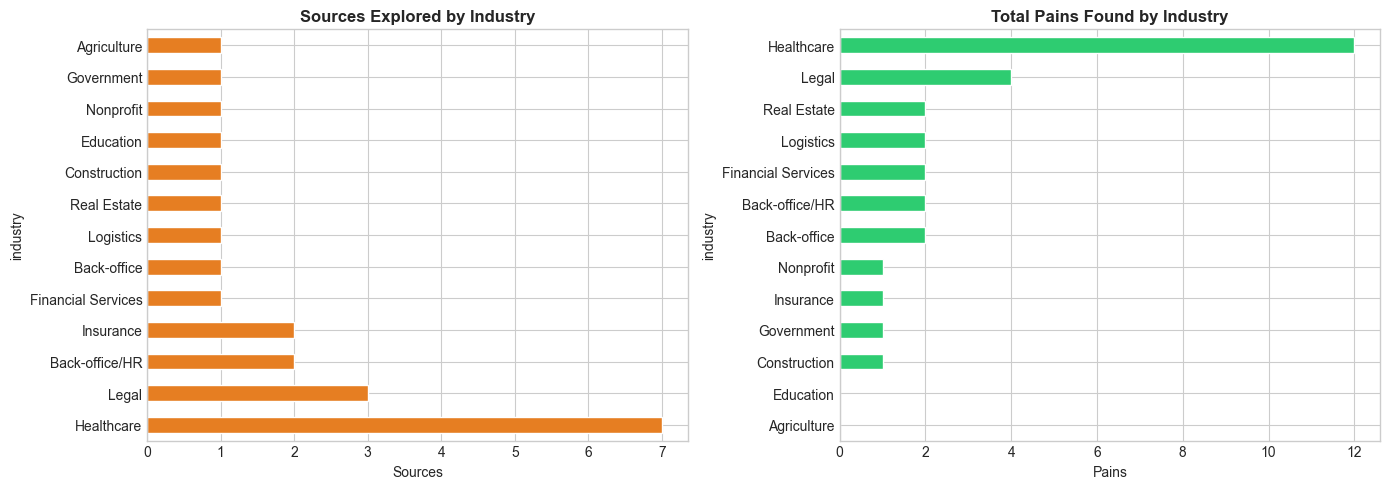

In [7]:
if len(sources) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    src_by_ind = sources["industry"].value_counts()
    src_by_ind.plot(kind="barh", ax=axes[0], color="#e67e22", edgecolor="white")
    axes[0].set_title("Sources Explored by Industry", fontweight="bold")
    axes[0].set_xlabel("Sources")
    axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    src_yield = sources.groupby("industry")["findings_count"].sum().sort_values(ascending=True)
    src_yield.plot(kind="barh", ax=axes[1], color="#2ecc71", edgecolor="white")
    axes[1].set_title("Total Pains Found by Industry", fontweight="bold")
    axes[1].set_xlabel("Pains")
    axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.show()
else:
    print("No sources explored yet. Start a research session!")